# Régression multiple

Une variable quantitative $Y$ dite à expliquer (ou encore, réponse, exogène, dépendante) est mise en relation avec $p$ variables quantitatives $X_1,\dots,X_p$ dites explicatives.

Les données sont supposées provenir de l'observation d'un échantillon statistique de taille $n$, $(n > p + 1)$ de $R^{(p+1)}$ :

$$
(x^1_i,\dots,x^j_i,\dots,x^p_i,y_i ),\quad i = 1,\dots,n.
$$

L'écriture du modèle linéaire dans cette situation conduit à supposer que l'espérance de $Y$ appartient au sous-espace de $R^n$ engendré par $\{1, X^1_i ,\dots , X^p_i \}$ où 1 désigne le vecteur de $R^n$. C'est-à-dire que les $(p + 1)$ variables aléatoires vérifient :

$$
Y_i =\beta_0 +\beta_1X_i^1 +\beta_2X_i^2 +\dots+\beta_pX^p_i +\varepsilon_i, \quad i = 2,\dots,n.
$$

Les $\varepsilon_i$ sont des termes d'erreur indépendants et identiquement distribués tels que $\mathbb E(\varepsilon_i)=0$ et ${\rm Var}(\varepsilon_i)=\sigma^2$.

Les données sont rangées dans une matrice $X\in \mathbb R^{n\times(p + 1)}$ de terme général $X_i^j$, dont la première colonne contient le vecteur 1 $(X_0^i = 1)$, et dans un vecteur $Y$ de terme général $Y_i$. En notant les vecteurs $\varepsilon = [\varepsilon_1, \dots, \varepsilon_p]′$ et $\beta= [\beta_0, \beta_1, \dots \beta_p ]′$ , le modèle s'écrit matriciellement :

$$
Y = X\beta + \varepsilon
$$

Conditionnellement à la connaissance des valeurs des $X_j$, les paramètres inconnus du modèle : le vecteur $\beta$ et $\sigma^2$ (paramètre de nuisance), sont estimés par minimisation des carrés des écarts. 

L'expression à minimiser sur $\beta\in \mathbb R^{p+1}$ s'écrit :
\begin{align*}
\sum_{i=1}^n(Y_i −\beta_0 −\beta_1X_i^1 −\dots−\beta_pX_i^p)^2&=\|Y−X\beta\|_2\\
&= Y′Y − 2\beta′X′Y + \beta′X′X\beta
\end{align*}

Par dérivation matricielle de la dernière équation on obtient les équations normales :
$$
X′Y − X′X\beta = 0
$$
dont la solution correspond bien à un minimum car la matrice hessienne $2X′X$
est semi définie-positive.
Nous faisons l'hypothèse supplémentaire que la matrice $X′X$ est inversible, c’est-à-dire que la matrice $X$ est de rang $(p + 1)$ et donc qu'il n'existe pas de colinéarité entre ses colonnes. Si cette hypothèse n'est pas vérifiée, il suffit en principe de supprimer des colonnes de X et donc des variables du modèle. Une approche de réduction de dimension (régression ridge, Lasso, PLS ...) est à mettre en œuvre.
Alors, l’estimation des paramètres $\beta_j$ est donnée par :


$$
\hat \beta= (X′X)^{-1}X′Y
$$

et les valeurs ajustées (ou estimées, prédites) de $Y$ ont pour expression :

$$
\hat Y􏰞= X\hat \beta􏰞 = X(X′X)^{−1}X′Y = HY
$$

où $H=X(X′X)^{−1}X′$. Géométriquement, c'est la matrice de projection orthogonale dans $R^n$ sur le sous-espace ${\rm Vect}(X)$ engendré par les vecteurs colonnes de $X$. On note
$$
e=Y−\hat Y􏰞 =Y−X\hat \beta􏰞=(I−H)Y
$$

## Régression ridge

Soit le modèle linéaire :

$$
 Y=\tilde X {\tilde{􏰟\beta}􏰟}+\varepsilon
$$

where 

$$
\begin{pmatrix} 
1 & X^1_1 & X^2_1 &\dots & X^p_1\\
1 & X^1_2 & X^2_2 &\dots & X^p_2 \\
\vdots & \vdots & \vdots & \vdots \\
1 & X^1_n & X^2_n &\dots & X^p_n
\end{pmatrix}
$$

$$
\tilde{\beta}=\begin{pmatrix} 
\beta_0\\
\beta_1\\
\vdots \\
\beta_p
\end{pmatrix},
\quad
{\beta}=\begin{pmatrix} 
\beta_1\\
\beta_2\\
\vdots \\
\beta_p
\end{pmatrix}
$$

où $X_0 = (1,1,\dots,1)′$, et $X$ désigne la matrice $\tilde X$􏰟 privée de sa première colonne. L'estimateur ridge est défini par un critère des moindres carrés, avec une pénalité de type $L_2$ :

L'estimateur ridge de $\tilde \beta$ dans le modèle
$$
 Y=\tilde X {\tilde{􏰟\beta}􏰟}+\varepsilon
$$
est défini par :

$$
\hat{\beta}_{\rm ridge}:={\arg\min}_{\beta\in \mathbb R^{(p+1)}}\left(\sum_{i=1}^n (Y_i- \sum_{j=0}^pX_i^j\beta_j)^2+\lambda\sum_{j=0}^p \beta_j^2 \right)
$$
où $\lambda$ est un paramètre positif, à choisir.

          x         y
0  1.047198  0.795794
1  1.117011  0.775370
2  1.186824  0.917377
3  1.256637  0.844052
4  1.326450  1.106248


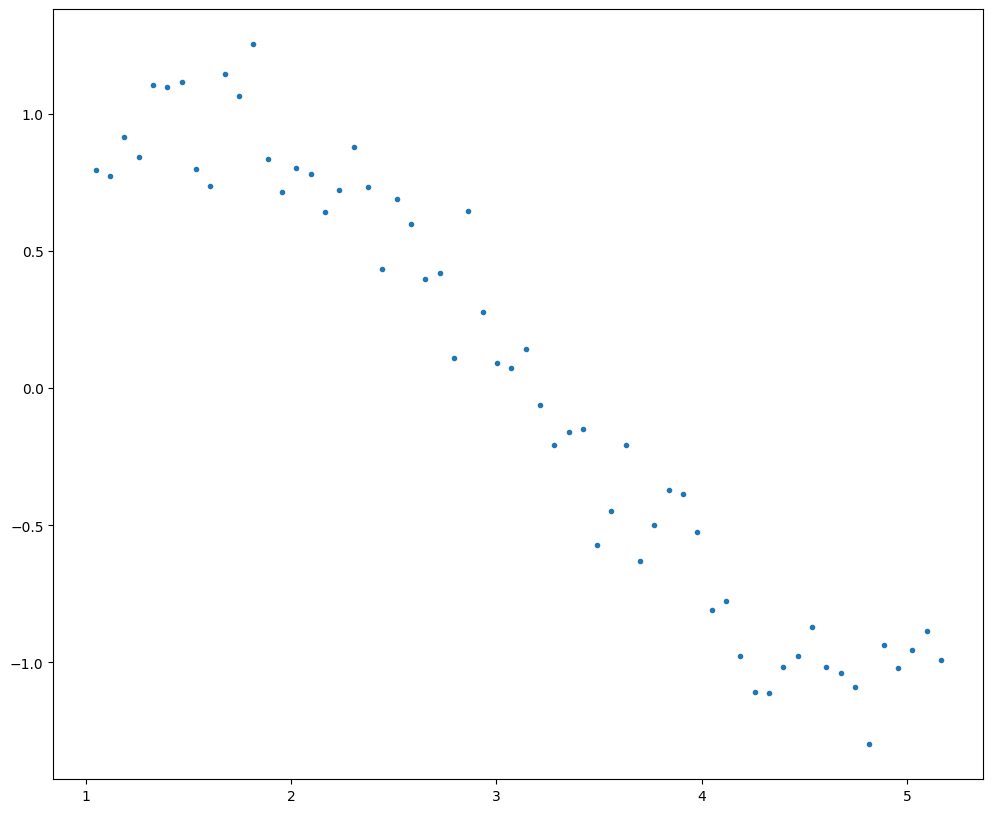

In [100]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 12, 10

#Define input array with angles from 60deg to 300deg converted to radians
x = np.array([i*np.pi/180 for i in range(60,300,4)])
#print(x)
np.random.seed(777)  #Jackpot
y = np.sin(x) + np.random.normal(0,0.15,len(x))
data = pd.DataFrame(np.column_stack([x,y]),columns=['x','y'])
print(data.head())


plt.plot(data['x'],data['y'],'.')



In [101]:
for i in range(2,16):  #power of 1 is already there
    colname = 'x_%d'%i      #new var will be x_power
    data[colname] = data['x']**i

In [102]:
print(data.head())
#print(data['x_2'].head())
#print(data[['x', 'x_2']].head())

          x         y       x_2       x_3       x_4       x_5       x_6  \
0  1.047198  0.795794  1.096623  1.148381  1.202581  1.259340  1.318778   
1  1.117011  0.775370  1.247713  1.393709  1.556788  1.738948  1.942424   
2  1.186824  0.917377  1.408551  1.671702  1.984016  2.354677  2.794587   
3  1.256637  0.844052  1.579137  1.984402  2.493673  3.133642  3.937850   
4  1.326450  1.106248  1.759470  2.333850  3.095735  4.106339  5.446854   

        x_7       x_8        x_9       x_10       x_11       x_12       x_13  \
0  1.381021  1.446202   1.514459   1.585938   1.660790   1.739176   1.821260   
1  2.169709  2.423588   2.707173   3.023942   3.377775   3.773011   4.214494   
2  3.316683  3.936319   4.671717   5.544505   6.580351   7.809718   9.268760   
3  4.948448  6.218404   7.814277   9.819710  12.339811  15.506664  19.486248   
4  7.224981  9.583578  12.712139  16.862020  22.366630  29.668222  39.353420   

        x_14       x_15  
0   1.907219   1.997235  
1   4.707635   5

In [103]:
data.shape

(60, 16)

$X$ : la matrice des données ou caractéristiques (features) (nrow: $N$, ncol: $M+1$)
$Y$ : la variable de sortie  (length:$N$)
$\hat Y$:les valeurs prédites de $Y$ (length:$N$)
$W$: les poids ou coefficients de régréssion (length: $M+1$).

Ici, $N$ est le nombre total des points données dont on dispose et $M$ est le nombre total de caractéristiques. $X$ a $M+1$ colonnes  car  elle a $M$ features et 1 intercept (constante).

Pour chaque point $i$ la prédiction est 

$$
\hat y_i=\sum_{j=0}^M w_j x_i^j
$$

L'expression à minimiser pour la régréssion est ${\rm RSS}$ (Residual Sum of Squares) définie par :

$$
{\rm RSS}(w):=\sum_{i=1}^N\left(y_i-\hat y_i\right)^2
$$

In [108]:
#Import Linear Regression model from scikit-learn.
# pip install sklearn 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def linear_regression(data, power, models_to_plot):
    
    #initialize predictors:
    predictors=['x']
    
    if power>=2:
        predictors.extend(['x_%d'%i for i in range(2,power+1)])
    
    #print(predictors)
    
    #Fit the model
    linreg = LinearRegression() #LinearRegression(normalize=True) #In theory, normalising the predictors 
                                             #will not affect the predictions made by linear regression. 
                                            #However, there are some practical reasons for doing so.
    linreg = make_pipeline(StandardScaler(), linreg)
    linreg.fit(data[predictors],data['y']) # find optimal weights w
    
    y_pred = linreg.predict(data[predictors])  # compute  ΣwX X=data[predictors]
    
    
    #Check if a plot is to be made for the entered power
    if power in models_to_plot:
        plt.subplot(models_to_plot[power])
        plt.tight_layout()
        plt.plot(data['x'],y_pred, linewidth=4, color = 'r')
        plt.plot(data['x'],data['y'],'.',color = 'b')
        plt.title('Plot for power: %d'%power)
    
    #Return the result in pre-defined format
    rss = sum((y_pred-data['y'])**2)

    ret = [rss]
    #Reminder
    #x = [1, 2, 3] x.append([4, 5]) print (x) [1, 2, 3, [4, 5]]
    #x = [1, 2, 3] x.extend([4, 5]) print (x) [1, 2, 3, 4, 5]
    
    # ret.extend([linreg.intercept_]) 
    # ret.extend(linreg.coef_)
    return ret

In [109]:
#Initialize a dataframe to store the results:
col = ['rss','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
#print(col)

ind = ['model_pow_%d'%i for i in range(1,16)]
#print(ind)

coef_matrix_simple = pd.DataFrame(index=ind, columns=col)
print(coef_matrix_simple)

              rss intercept coef_x_1 coef_x_2 coef_x_3 coef_x_4 coef_x_5  \
model_pow_1   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_2   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_3   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_4   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_5   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_6   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_7   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_8   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_9   NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_10  NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_11  NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_12  NaN       NaN      NaN      NaN      NaN      NaN      NaN   
model_pow_13

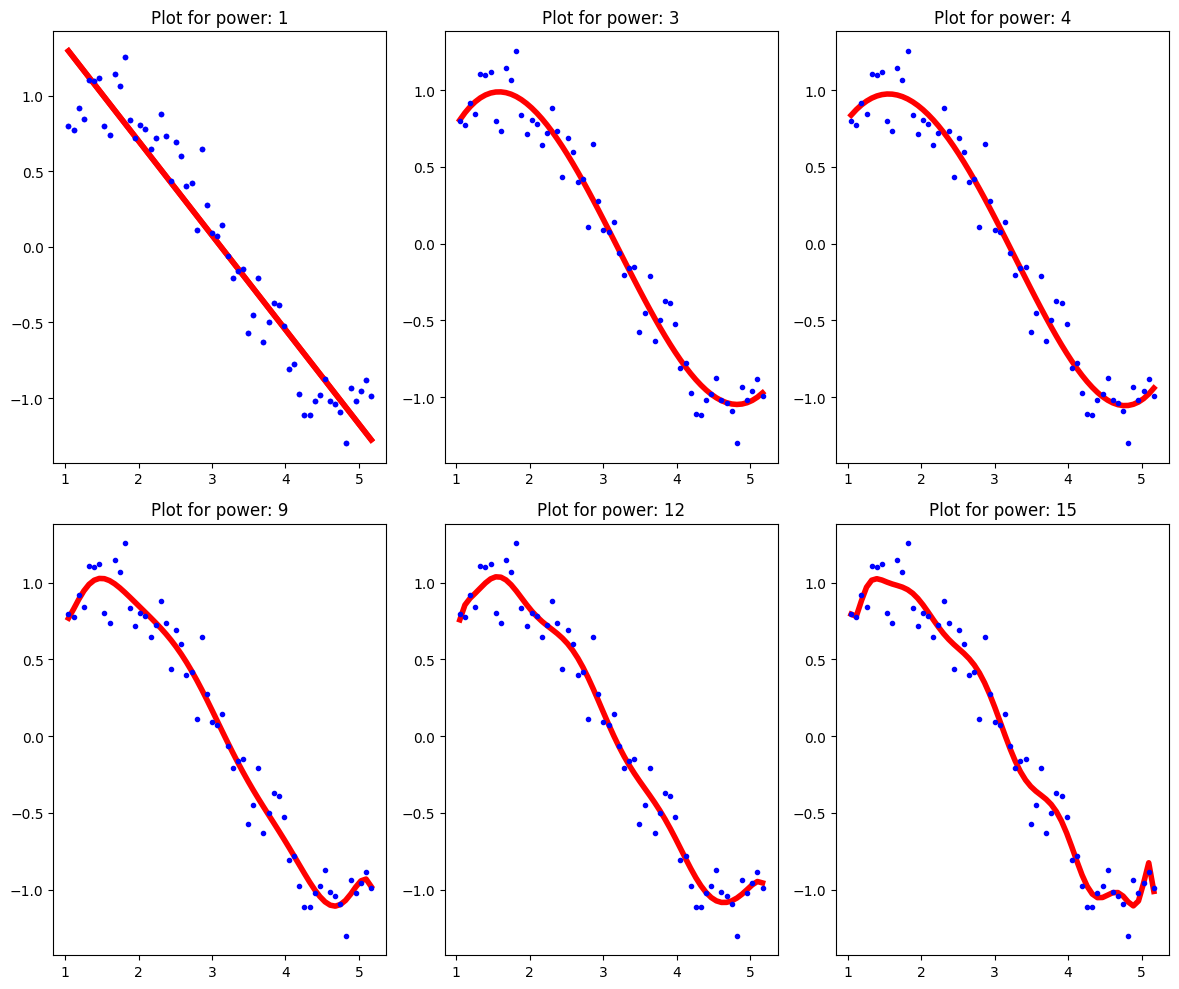

In [110]:
#Define the powers for which a plot is required:
models_to_plot = {1:231,3:232,4:233,9:234,12:235,15:236} #dictionnary where 1, 3, 6, 9, 12 and 15 are 
                                                        #the powers to be plot

#for power in models_to_plot:
#    print(power)
#    print(models_to_plot[power])

ret=linear_regression(data, power=1, models_to_plot=models_to_plot)


#Iterate through all powers and assimilate results
for i in range(1,16):
    coef_matrix_simple.iloc[i-1,0:i+2] = linear_regression(data, power=i, models_to_plot=models_to_plot)
#pour i=1
#ret=[rss,intecept, coef_1]

In [111]:
#Set the display format to be scientific for ease of analysis
#pd.options.display.float_format = '{:,.2g}'.format
coef_matrix_simple

,rss,intercept,coef_x_1,coef_x_2,coef_x_3,coef_x_4,coef_x_5,coef_x_6,coef_x_7,coef_x_8,coef_x_9,coef_x_10,coef_x_11,coef_x_12,coef_x_13,coef_x_14,coef_x_15
model_pow_1,3.00292,3.00292,3.00292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_2,2.889391,2.889391,2.889391,2.889391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_3,1.234969,1.234969,1.234969,1.234969,1.234969,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_4,1.225881,1.225881,1.225881,1.225881,1.225881,1.225881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_5,1.202404,1.202404,1.202404,1.202404,1.202404,1.202404,1.202404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_6,1.198729,1.198729,1.198729,1.198729,1.198729,1.198729,1.198729,1.198729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_7,1.198552,1.198552,1.198552,1.198552,1.198552,1.198552,1.198552,1.198552,1.198552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_8,1.185251,1.185251,1.185251,1.185251,1.185251,1.185251,1.185251,1.185251,1.185251,1.185251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_9,1.161835,1.161835,1.161835,1.161835,1.161835,1.161835,1.161835,1.161835,1.161835,1.161835,1.161835,NaN,NaN,NaN,NaN,NaN,NaN
model_pow_10,1.154293,1.154293,1.154293,1.154293,1.154293,1.154293,1.154293,1.154293,1.154293,1.154293,1.154293,1.154293,NaN,NaN,NaN,NaN,NaN


## Ridge régression

\begin{equation}
{\rm RSS}(w):=\sum_{i=1}^N\left(y_i-\sum_{j=0}^Mw_jx_i^j\right)^2+\lambda \sum_{j=0}^M w_j^2\tag{E}
\end{equation}

In [112]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def ridge_regression(data, predictors, alpha, models_to_plot={}): # alpha=lambda de la formule (E)
   
    #Fit the model
    ridgereg = Ridge(alpha=alpha)
    ridgereg = make_pipeline(StandardScaler(), ridgereg)

    ridgereg.fit(data[predictors],data['y']) #trouver w optimal qui minimise (E) 
    y_pred = ridgereg.predict(data[predictors])# donne \hat Y

    
    
    #Check if a plot is to be made for the entered alpha
    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'],y_pred, linewidth=4, color = 'r')
        plt.plot(data['x'],data['y'],'.',color = 'b')
        plt.title('Plot for alpha: %.3g'%alpha)
    
    #Return the result in pre-defined format
    rss = sum((y_pred-data['y'])**2)
    ret = [rss]
    # ret.extend([ridgereg.intercept_])
    # ret.extend(ridgereg.coef_)
    return ret

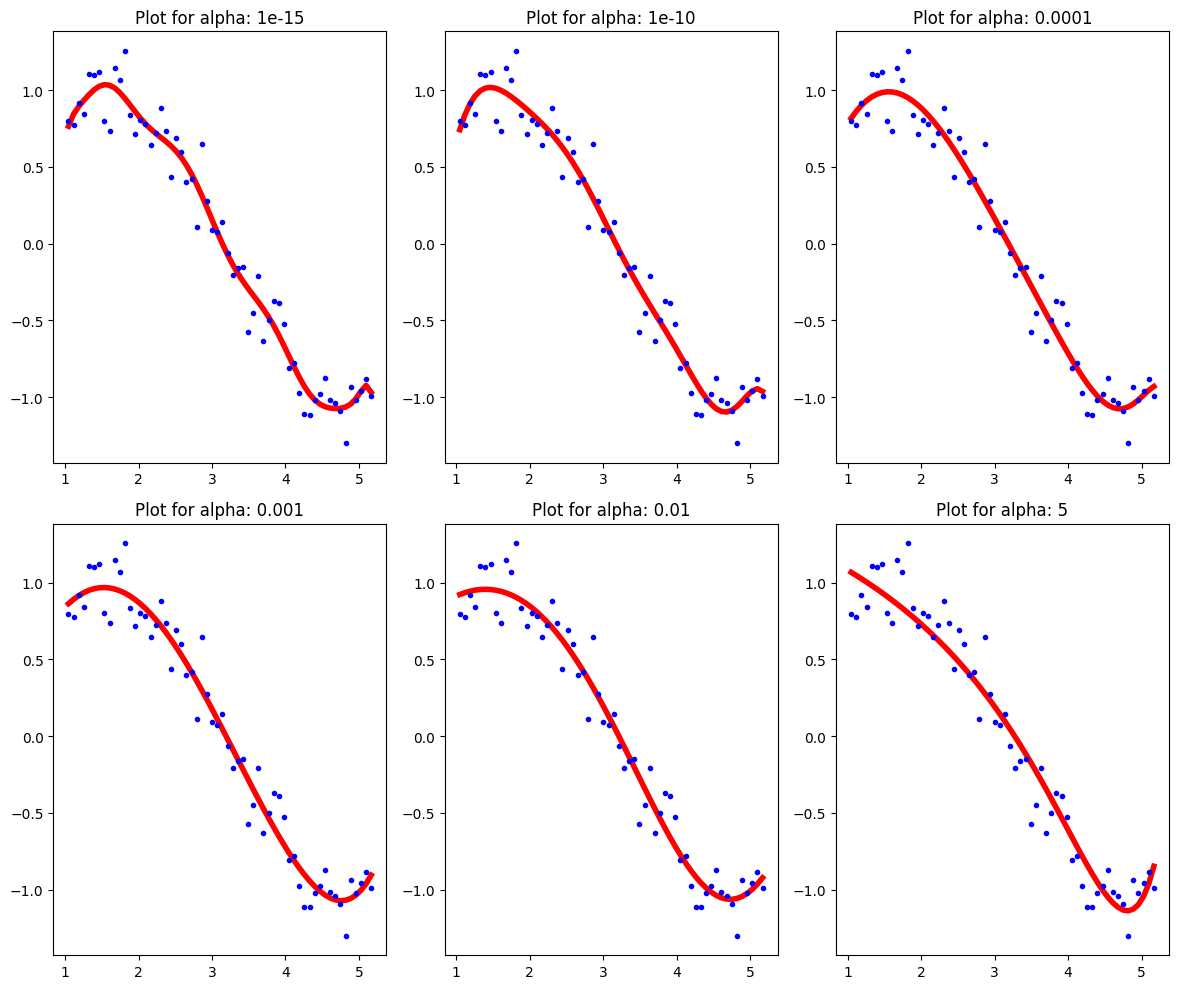

In [113]:
rcParams['figure.figsize'] = 12, 10

#Initialize predictors to be set of 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

#Set the different values of alpha to be tested
alpha_ridge = [1e-15, 1e-10, 1e-8, 1e-4, 1e-3,1e-2, 1, 5, 10, 20] #10 puissances

#Initialize the dataframe for storing coefficients.
col = ['rss','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_ridge[i] for i in range(0,10)]
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col)

models_to_plot = {1e-15:231, 1e-10:232, 1e-4:233, 1e-3:234, 1e-2:235, 5:236}
for i in range(10):
    coef_matrix_ridge.iloc[i,] = ridge_regression(data, predictors, alpha_ridge[i], models_to_plot)

In [114]:
#Set the display format to be scientific for ease of analysis
#pd.options.display.float_format = '{:,.2g}'.format
coef_matrix_ridge

,rss,intercept,coef_x_1,coef_x_2,coef_x_3,coef_x_4,coef_x_5,coef_x_6,coef_x_7,coef_x_8,coef_x_9,coef_x_10,coef_x_11,coef_x_12,coef_x_13,coef_x_14,coef_x_15
alpha_1e-15,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646,1.11646
alpha_1e-10,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207,1.164207
alpha_1e-08,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191,1.173191
alpha_0.0001,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979,1.198979
alpha_0.001,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988,1.224988
alpha_0.01,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505,1.266505
alpha_1,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142,1.607142
alpha_5,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701,1.786701
alpha_10,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877,1.989877
alpha_20,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658,2.54658


In [115]:
# determining the number of zeros in each row of the coefficients data set:
coef_matrix_ridge.apply(lambda x: sum(x.values==0),axis=1)

alpha_1e-15     0
alpha_1e-10     0
alpha_1e-08     0
alpha_0.0001    0
alpha_0.001     0
alpha_0.01      0
alpha_1         0
alpha_5         0
alpha_10        0
alpha_20        0
dtype: int64

## Lasso Régression

$$
{\rm RSS}(w):=\sum_{i=1}^N\left(y_i-\sum_{j=0}^Mw_jx_i^j\right)^2+\lambda \sum_{j=0}^M |w_j|
$$

In [126]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
rcParams['figure.figsize'] = 12, 10
def lasso_regression(data, predictors, alpha, models_to_plot={}):
    
    #Fit the model
    lassoreg = Lasso(alpha=alpha, max_iter=int(1e5))
    # lassoreg = make_pipeline(StandardScaler(), lassoreg)
    lassoreg.fit(data[predictors],data['y'])
  
    y_pred = lassoreg.predict(data[predictors])
    
    #Check if a plot is to be made for the entered alpha
    if alpha in models_to_plot:
        plt.subplot(models_to_plot[alpha])
        plt.tight_layout()
        plt.plot(data['x'],y_pred,linewidth=4, color = 'r')
        plt.plot(data['x'],data['y'],'.',color = 'b')
        plt.title('Plot for alpha: %.3g'%alpha)
    
    #Return the result in pre-defined format
    rss = sum((y_pred-data['y'])**2)
    ret = [rss]
    ret.extend([lassoreg.intercept_])
    ret.extend(lassoreg.coef_)
    return ret

c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.030e-01, tolerance: 3.718e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.030e-01, tolerance: 3.718e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

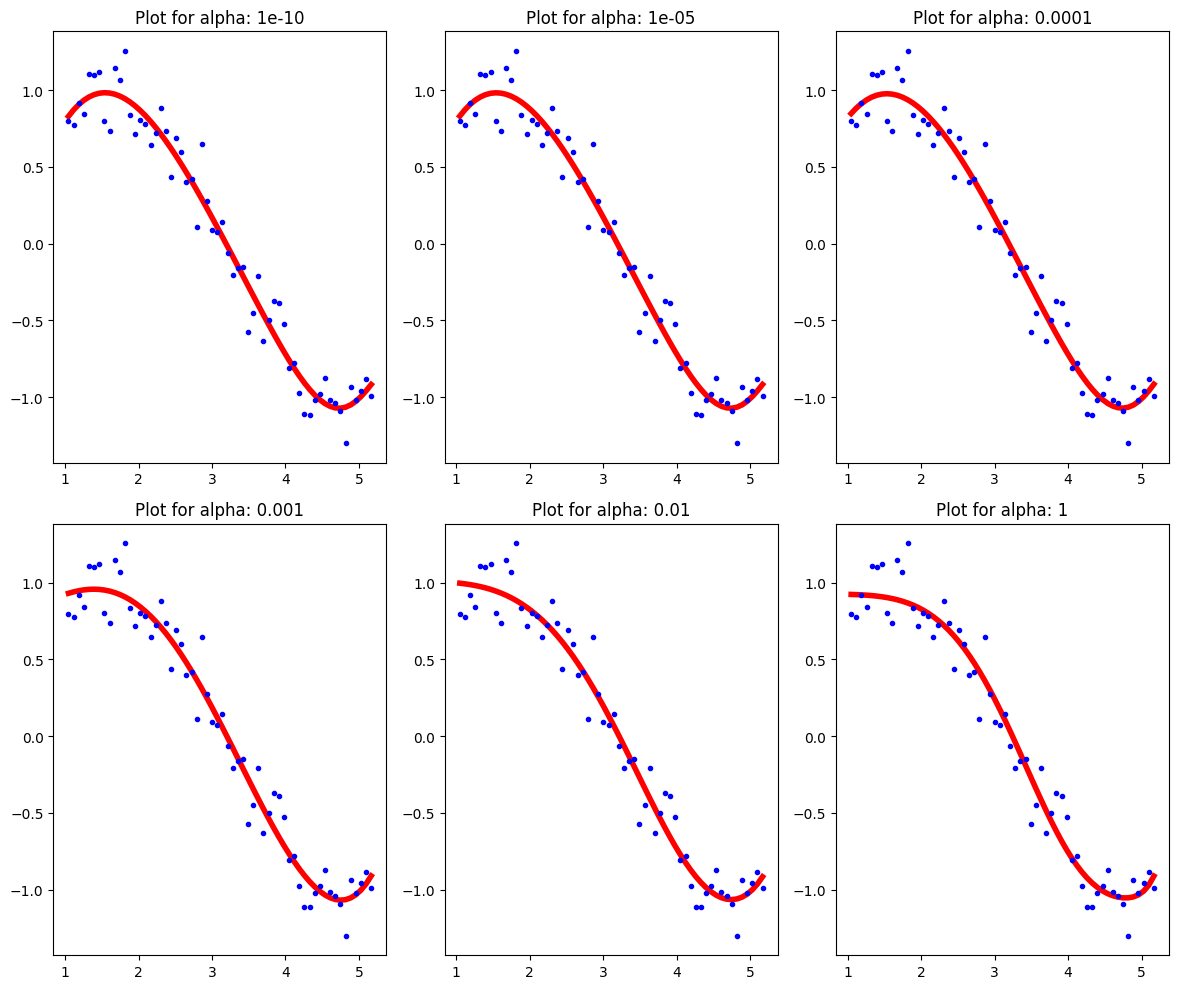

In [127]:
#Initialize predictors to all 15 powers of x
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])

#Define the alpha values to test
alpha_lasso = [1e-15, 1e-10, 1e-8, 1e-5,1e-4, 1e-3,1e-2, 1, 5, 10]

#Initialize the dataframe to store coefficients
col = ['rss','intercept'] + ['coef_x_%d'%i for i in range(1,16)]
ind = ['alpha_%.2g'%alpha_lasso[i] for i in range(0,10)]
coef_matrix_lasso = pd.DataFrame(index=ind, columns=col)

#Define the models to plot
models_to_plot = {1e-10:231, 1e-5:232,1e-4:233, 1e-3:234, 1e-2:235, 1:236}

#Iterate over the 10 alpha values:
for i in range(10):
    coef_matrix_lasso.iloc[i,] = lasso_regression(data, predictors, alpha_lasso[i], models_to_plot)

In [128]:
#pd.options.display.float_format = '{:,.2g}'.format
coef_matrix_lasso

,rss,intercept,coef_x_1,coef_x_2,coef_x_3,coef_x_4,coef_x_5,coef_x_6,coef_x_7,coef_x_8,coef_x_9,coef_x_10,coef_x_11,coef_x_12,coef_x_13,coef_x_14,coef_x_15
alpha_1e-15,1.206075,-0.784268,2.527844,-1.021511,0.061823,0.012459,0.000475,-0.000161,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_1e-10,1.206075,-0.784268,2.527844,-1.021511,0.061823,0.012459,0.000475,-0.000161,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_1e-08,1.206076,-0.784234,2.527785,-1.021476,0.061815,0.012459,0.000475,-0.000161,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_1e-05,1.206642,-0.749947,2.468236,-0.986587,0.054199,0.012677,0.000534,-0.000154,-0.000042,-0.000005,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_0.0001,1.212692,-0.451278,1.958392,-0.697252,-0.003956,0.012793,0.001122,-0.000086,-0.000038,-0.000006,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0
alpha_0.001,1.265313,0.711026,0.155153,0.163525,-0.103184,-0.007,0.002889,0.000342,0.000001,-0.000006,-0.000001,-0.0,0.0,0.0,0.0,0.0,-0.0
alpha_0.01,1.330416,1.00913,0.0,0.0,0.0,-0.008997,-0.002765,0.000564,0.000087,0.000003,-0.000001,-0.0,-0.0,-0.0,0.0,0.0,0.0
alpha_1,1.387253,0.925302,-0.0,-0.0,-0.0,-0.0,-0.0,-0.002291,0.00019,0.0001,0.000001,-0.000001,-0.0,-0.0,-0.0,0.0,0.0
alpha_5,1.605066,0.867163,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000528,-0.000449,0.000075,0.00002,-0.0,-0.0,-0.0,-0.0,0.0,0.0
alpha_10,1.747649,0.843496,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000516,-0.0,0.000035,0.000001,-0.0,-0.0,-0.0,-0.0,0.0


In [129]:
coef_matrix_lasso.apply(lambda x: sum(x.values==0),axis=1)

alpha_1e-15     0
alpha_1e-10     0
alpha_1e-08     0
alpha_1e-05     0
alpha_0.0001    0
alpha_0.001     0
alpha_0.01      3
alpha_1         5
alpha_5         5
alpha_10        7
dtype: int64

# Exercice:

En reprenant les mêmes data que précédemment, illustrer l'efficaité la méthode Elasticnet qui est une méthode hybride qui combine à la fois Loss où le RSS (Residual Sum of Squares) associé est définie par 
$$
{\rm RSS}(w):=\sum_{i=1}^N\left(y_i-\sum_{j=0}^Mw_jx_i^j\right)^2+\lambda \sum_{j=0}^M |w_j| +(1-\lambda)\sum_{j=0}^M |w_j|^2
$$

- Illustrer le même type de tablaux et de graphiques que ce qu'on a fait pour Ridge et Lasso.
- Quelle valeur optimale de $\lambda$ choisiriez-vous ?
- Conclure. 

*******


c:\Users\lione\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.054e-01, tolerance: 3.718e-03
  model = cd_fast.enet_coordinate_descent(


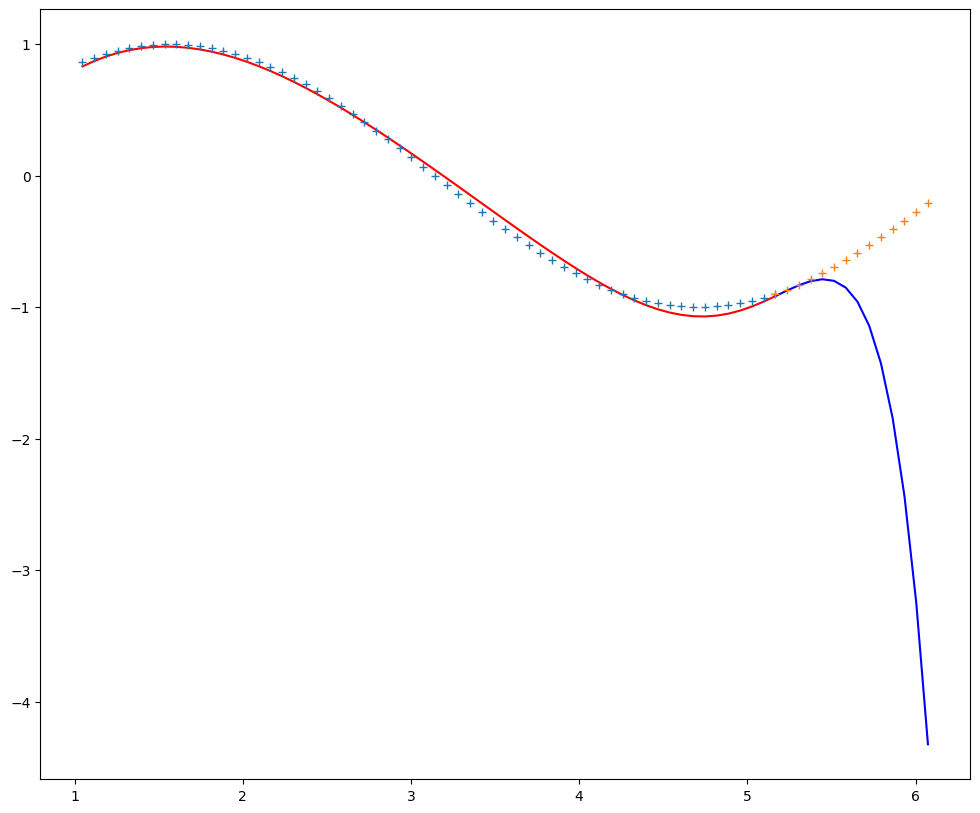

In [130]:
alpha=1e-5




# x training data 
predictors=['x']
predictors.extend(['x_%d'%i for i in range(2,16)])
beta_opt=np.matrix(lasso_regression(data, predictors, alpha , models_to_plot={111}))
beta_opt=beta_opt[0,1:]
#print(np.shape(beta_opt))


print('*******')
# Test data 

xx=np.zeros((16,len(range(60,300,4))))
#xx=np.zeros((16,110))

for j in range(16):

    xx[j,:] = np.array([(i*np.pi/180)**j for i in range(60,300,4)])

#print(xx)


y_pred=np.dot(beta_opt,xx)


plt.plot(xx[1,:],np.transpose(y_pred),'r')

plt.plot(xx[1,:], np.sin(xx[1,:]),'+')

# prediction
xx=np.zeros((16,len(range(296,350,4))))


for j in range(16):

    xx[j,:] = np.array([(i*np.pi/180)**j for i in range(296,350,4)])

#print(xx)


y_pred=np.dot(beta_opt,xx)


plt.plot(xx[1,:],np.transpose(y_pred),'b')

plt.plot(xx[1,:], np.sin(xx[1,:]),'+')





On s'intéresse aux indices 'Apple' et le 'MSFT'  pour la période du 1/1/2014 au 1/1/2015, puis faire une régréssion linéaire du 'Apple' sur 'MSFT'. Une alternative à LInearRegression de Sklearn est OLS de statsmodels.

In [131]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import statsmodels.api as sm

from pandas_datareader import DataReader
from datetime import datetime

import yfinance as yf


from statsmodels import regression

C:\Users\lione\AppData\Local\Temp\ipykernel_30368\3650159847.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Apple = yf.download('AAPL', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
C:\Users\lione\AppData\Local\Temp\ipykernel_30368\3650159847.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  Microsoft = yf.download('MSFT', start=start_date, end=end_date )


Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2014-01-02  17.156698  17.277667  17.122269  17.235793  234684800
2014-01-03  16.779833  17.174374  16.762772  17.148321  392467600
2014-01-06  16.871338  16.960357  16.550927  16.670345  412610800
2014-01-07  16.750681  16.934304  16.684924  16.883435  317209200
2014-01-08  16.856764  16.921900  16.708811  16.712531  258529600
...               ...        ...        ...        ...        ...
2014-12-24  24.831680  24.986864  24.831680  24.958044   57918400
2014-12-26  25.270636  25.388132  24.831687  24.851638  134884000
2014-12-29  25.252903  25.443556  25.206346  25.226299  110395600
2014-12-30  24.944748  25.255117  24.853855  25.193043  119526000
2014-12-31  24.470324  25.079976  24.432636  25.011252  165613600

[252 rows x 5 columns]


[*********************100%***********************]  1 of 1 completed


beta_0: -8.836586160541257
beta_1: 0.8146123079590541


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     2138.
Date:                Fri, 19 Dec 2025   Prob (F-statistic):          1.61e-124
Time:                        10:19:41   Log-Likelihood:                -354.47
No. Observations:                 252   AIC:                             712.9
Df Residuals:                     250   BIC:                             720.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.8366      0.633    -13.962      0.000     -10.083      -7.590
x1             0.8146      0.018     46.242      0.000       0.780       0.849
==============================================================================
Omnibus:                        9.435   Durbin-Watson:                   0.148
Prob(Omnibus):                  0.009   Jarque-Bera (JB):                9.682
Skew:                          -0.453   Prob(JB):                      0.00790
Kurtosis:                       2.683   Cond. No.                         364.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

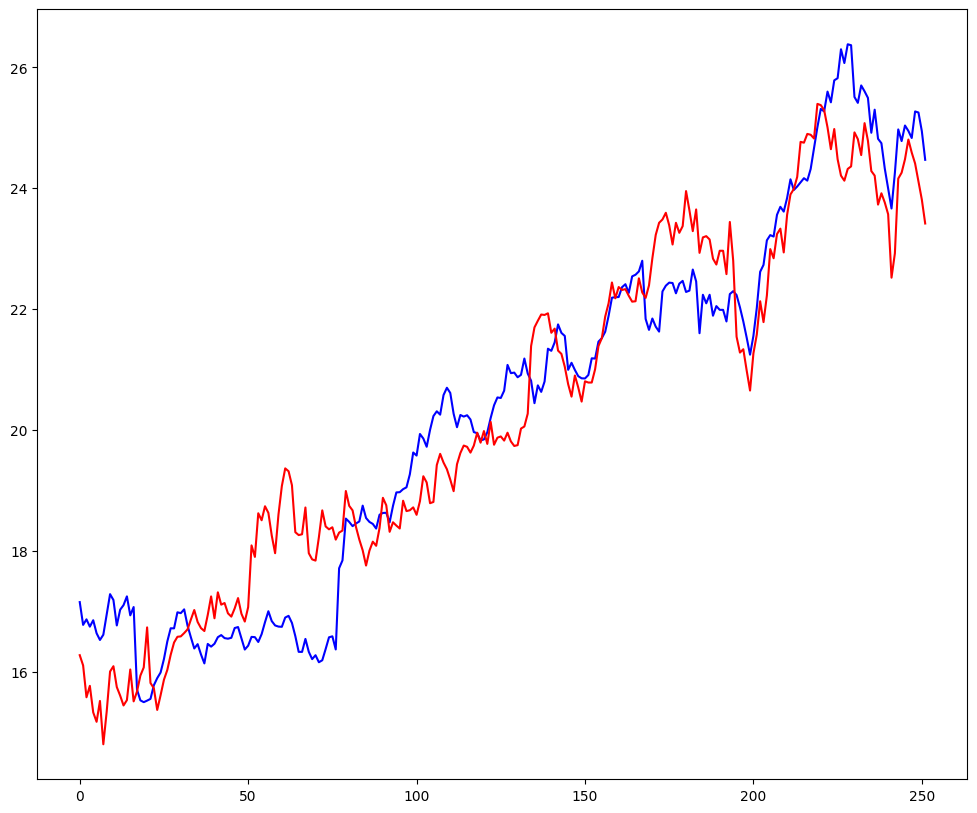

In [ ]:
start_date = '2014-01-01'
end_date = '2015-01-01'

Apple = yf.download('AAPL', start=start_date, end=end_date)



print(Apple)
asset1=Apple['Close'].values

Microsoft = yf.download('MSFT', start=start_date, end=end_date )
asset2=Microsoft['Close'].values

reglinear=regression.linear_model.OLS(asset1, sm.add_constant(asset2)).fit()

print('beta_0:', reglinear.params[0])
print('beta_1:', reglinear.params[1])

prediction1=reglinear.params[0] + reglinear.params[1] * asset2

plt.plot(asset1,'b') # observed data Apple
plt.plot(prediction1,'r') # linear regression prediction

reglinear.summary()

Pour faire une régression multilple on prend en compte une deuxième composante explicative le 'SPY'. Faites la régression multiple puis tracer la courbe de prédiction et comparer avec la régression linéaire. 

Ind: Utilser OLS mais en faisant une concaténation de asset2 et asset3 (SPY) avec la commande :
np.column_stack((asset2,asset3))

C:\Users\lione\AppData\Local\Temp\ipykernel_30368\2414577487.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  SPY=yf.download('SPY', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

beta_0: -27.745289614052542
beta_1: 0.40144494933051933
beta_2: 0.21173619175125585


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     1541.
Date:                Fri, 19 Dec 2025   Prob (F-statistic):          5.67e-141
Time:                        11:07:03   Log-Likelihood:                -312.01
No. Observations:                 252   AIC:                             630.0
Df Residuals:                     249   BIC:                             640.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -27.7453      1.968    -14.102      0.000     -31.620     -23.870
x1             0.4014      0.044      9.129      0.000       0.315       0.488
x2             0.2117      0.021      9.988      0.000       0.170       0.253
==============================================================================
Omnibus:                        1.745   Durbin-Watson:                   0.172
Prob(Omnibus):                  0.418   Jarque-Bera (JB):                1.813
Skew:                          -0.166   Prob(JB):                        0.404
Kurtosis:                       2.751   Cond. No.                     6.07e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.07e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

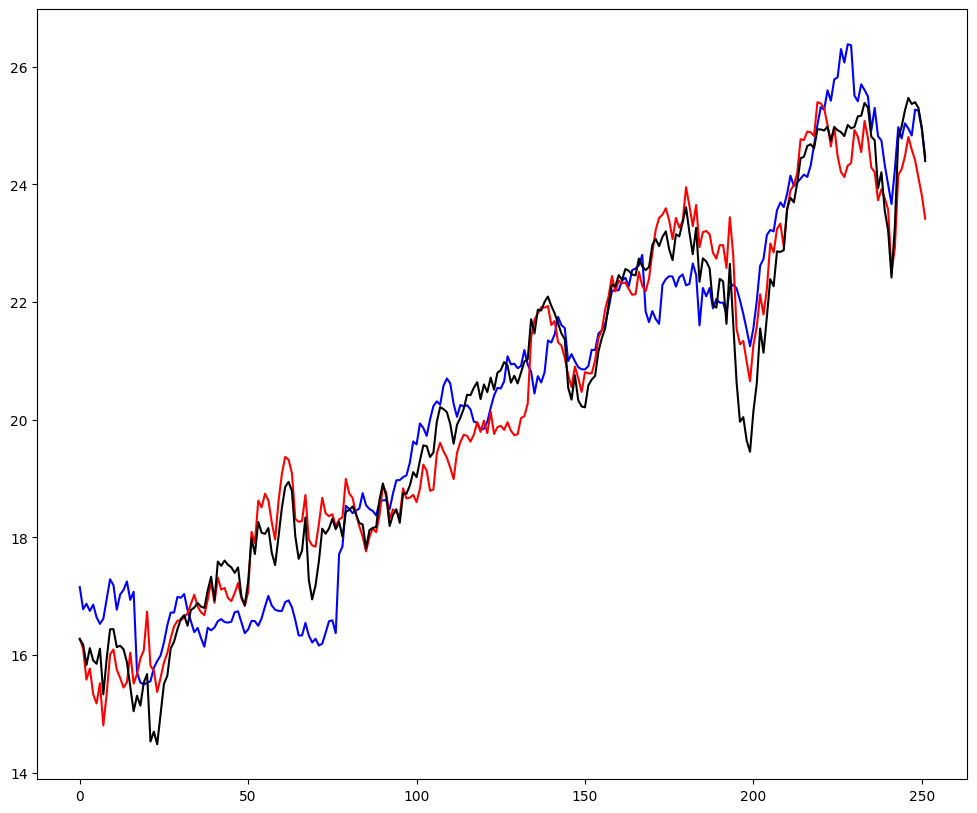

In [132]:
SPY=yf.download('SPY', start=start_date, end=end_date)
asset3=SPY['Close'].values

regmultilinear=regression.linear_model.OLS(asset1, sm.add_constant(np.column_stack((asset2,asset3)))).fit()


print('beta_0:', regmultilinear.params[0])
print('beta_1:', regmultilinear.params[1])
print('beta_2:', regmultilinear.params[2])

prediction2=regmultilinear.params[0]+ regmultilinear.params[1]*asset2 + regmultilinear.params[2]*asset3


plt.plot(asset1,'b')
plt.plot(prediction1,'r')
plt.plot(prediction2, 'k')

regmultilinear.summary()

Question: retrouver RSS pour chacun des deux modèles ?

In [134]:
rss1 = sum((prediction1-asset1)**2)
rss2 = sum((prediction2-asset1)**2)

print(rss1, rss2)

[245.86700752] [175.53815273]
